<a href="https://colab.research.google.com/github/Flurbs222/NumericalAnalysis-Projects/blob/main/Project_3-LinearEQSolver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team Project 3 - Solving a System of Linear Equations

In this project, we compare the performance of three different methods of solving a system of linear equations. The lesson that you may get is that finding an efficient method is not an unnecessary complication.

For this project, <b>DO NOT</b> use the 'solve' or 'inv' method in the linear algebra package! You have to create your own code for it.

1. (5 pts) Create a function **randmat(n)** which returns a random square matrix constructed as the following recipe.
<ul>
    <li>The size of the matrix is $n \times n$.</li>
    <li>Each off-diagonal entry ($a_{ij}$ where $i \ne j$) is a random number in $[0, 1)$. A random number can be constructed by the random method (see <a href="https://docs.scipy.org/doc/numpy/reference/routines.random.html">here</a>).</li>
    <li>A diagonal entry $a_{ii}$ is a random number in $[n, n+1)$. (This condition guarantees that the matrix $(a_{ij})$ is strictly diagonally dominant, hence invertible.)</li>
</ul>

And create a function **randvec(n)** which returns an $n$-dimensional random vector whose entries are random numbers in $[0, 100)$.

In [ ]:
import numpy as np

def randmat(n):
    # Generate a random matrix with all entries in [0, 1)
    A = np.random.rand(n, n)
    # Replace diagonal entries with random numbers in [n, n+1)
    diag_entries = np.random.uniform(n, n + 1, size=n)
    np.fill_diagonal(A, diag_entries)
    return A

def randvec(n):
    return np.random.uniform(0, 100, size=n)

2. (10 pts) Create a function **GaussElim(A, b)** which solves a system of linear equations $Ax = b$ by using Gaussian Elimination with the partial pivoting.

In [ ]:
def GaussElim(A, b):
    A = A.copy()
    b = b.copy()
    n = len(b)
    for i in range(n):
        # Find the pivot row
        pivot = np.argmax(np.abs(A[i:, i])) + i

        # Check for singularity
        if np.abs(A[pivot, i]) < 0.0000001:
            raise ValueError("Matrix is singular or nearly singular.")

        # Swap the row
        if pivot != i:
            A[[i, pivot]] = A[[pivot, i]]
            b[i], b[pivot] = b[pivot], b[i]

        # Eliminate
        for j in range(i+1, n):
            factor = A[j, i] / A[i, i]
            A[j, i:] -= factor * A[i, i:]
            b[j] -= factor * b[i]

    # Back substitution
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (b[i] - np.dot(A[i, i+1:], x[i+1:])) / A[i, i]

    return x

tA = randmat(3)
tb = randvec(3)
print(GaussElim(tA, tb))

[27.10931721 16.63305727 -1.34016719]


3. (10 pts) Create a function **InvMat(A,b)** which solves a system of linear equations $Ax = b$ with the "theoretically simplest method," that is, computing $x = A^{-1}b$. Compute the inverse matrix as the following:
<ul>
    <li>Make an augmented matrix $[A | I]$ where $I$ is the $n \times n$ identity matrix.</li>
    <li>Apply elementary row operations until the left half $A$ on $[A| I]$ becomes $I$, so it looks $[I | B]$.</li>
    <li>Then the right half of the augmented matrix $B$ is $A^{-1}$.</li>
</ul>

In [ ]:
def InvMat(A, b):
    A = A.copy()
    b = b.copy()
    n = len(b)

    # Construct [A | I]
    aug = np.hstack((A, np.eye(n)))

    # Forward elimination
    for i in range(n):
        pivot = np.argmax(np.abs(aug[i:, i])) + i
        if np.abs(aug[pivot, i]) < 0.0000001:
            raise ValueError("Matrix is singular or nearly singular.")

        # Swap the row
        if pivot != i:
            aug[[i, pivot]] = aug[[pivot, i]]

        # Let pivot become 1
        aug[i] = aug[i] / aug[i, i]

        # Eliminate the entries below the pivot
        for j in range(i+1, n):
            factor = aug[j, i]
            aug[j] -= factor * aug[i]

    # Backward elimination
    for i in range(n-1, -1, -1):
        for j in range(i-1, -1, -1):
            factor = aug[j, i]
            aug[j] = aug[j] - factor * aug[i]

    # The right half is the inverse of A
    A_inv = aug[:, n:]

    return A_inv @ b

print(InvMat(tA, tb))

[27.10931721 16.63305727 -1.34016719]


4. (10 pts) Create a function **Jacobi(A, b, err)** which solves a system of linear equations $Ax = b$ by using Jacobi interation method. Set $x^{(0)} = \vec{0}$. We stop the iteration when the estimation of the error $||x^{(k)} - x^{(k-1)}||_\infty$ is less than err or $k = 1000$. (Here $x^{(k)}$ is the $k$-th output of the iteration).

In [ ]:
def Jacobi(A, b, err):
    n = len(b)
    d = np.diag(A)

    if np.any(np.abs(d) < 0.0000001):
        raise ValueError("Zero diagonal element encountered; Jacobi method cannot proceed.")
    D = np.diag(d)
    D_inv = np.diag(1.0 / d)

    # Initial guess
    x_old = np.zeros(n)

    # Iterate up to 1000 iterations
    for k in range(1, 1001):
        x_new = D_inv @ (D - A) @ x_old + D_inv @ b
        # Check for convergence
        if max(abs(x_new - x_old)) < err:
            print("Convergence reached at iteration", k)
            return x_new

        x_old = x_new.copy()

    print("Maximum iterations reached.")
    return x_new

print(Jacobi(tA, tb, 0.00001))

Convergence reached at iteration 11
[27.10931737 16.63305749 -1.3401668 ]


5. (10 pts) Create a function **GaussSeidel(A, b, err)** which solves a system of linear equations $Ax = b$ by using Gauss-Seidel interation method. Set $x^{(0)} = \vec{0}$. We stop the iteration when the estimation of the error $||x^{(k)} - x^{(k-1)}||_\infty$ is less than err or $k = 1000$. (Here $x^{(k)}$ is the $k$-th output of the iteration).

In [ ]:
import numpy as np

def forward_substitution(L, b):
    # Assume L is a invertible lower triangular matrix and solve Lx = b
    L = L.copy()
    b = b.copy()
    n = len(b)
    x = np.zeros(n)
    for i in range(n):
        x[i] = (b[i] - np.dot(L[i, :i], x[:i])) / L[i, i]
    return x


def GaussSeidel(A, b, err):
    A = A.copy()
    b = b.copy()
    n = len(b)

    # Extract D, L, U from A
    D = np.diag(np.diag(A))
    L = -np.tril(A, k=-1)
    U = -np.triu(A, k=1)

    # Initial guess
    x_old = np.zeros(n)

    # Iteration loop
    for k in range(1, 1001):

        # Solve (D - L)x_new = Ux_old + b
        x_new = forward_substitution(D - L, U @ x_old + b)

        # Check for convergence using the infinity norm
        if max(abs(x_new - x_old)) < err:
            print("Convergence reached at iteration", k)
            return x_new

        x_old = x_new.copy()

    print("Maximum iterations reached without full convergence.")
    return x_new

print(GaussSeidel(tA, tb, 0.00001))

Convergence reached at iteration 5
[27.1093172  16.63305726 -1.34016718]


6. (5 pts) For $n = 100, 200, 300, \cdots , 1000$, create a random $n \times n$ matrix $A$ and a random $n$-dimensional vector $b$. Solve the system of linear equations $Ax = b$ by using **GaussElim(A, b)**, **InvMat(A, b)**, **Jacobi(A, b, err)**, and **GaussSeidel(A, b, err)**. Use $10^{-6}$ for the error tolerance. Record the excution time for each method. Plot the graph of the excution time for those three methods on the same plane.

For the computation of the excution time, you may use the following method:

In [ ]:
import time

start = time.time()
"the code you want to test stays here"
end = time.time()

print(end - start)

5.1021575927734375e-05


Convergence reached at iteration 20
Convergence reached at iteration 8
Convergence reached at iteration 19
Convergence reached at iteration 7
Convergence reached at iteration 19
Convergence reached at iteration 7
Convergence reached at iteration 18
Convergence reached at iteration 7
Convergence reached at iteration 18
Convergence reached at iteration 7


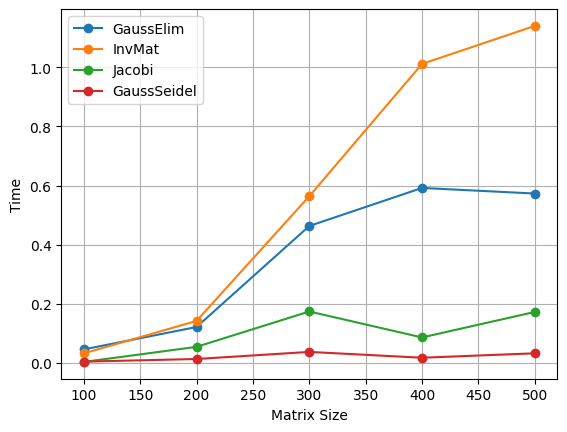

In [ ]:
import matplotlib.pyplot as plt

#n_values = list(range(100, 1001, 100))
n_values = list(range(100, 501, 100))
# Lists to store the execution times for each method
times_ge = []       # Gaussian Elimination
times_inv = []      # Inverse method via augmented matrix
times_jacobi = []   # Jacobi iteration
times_gs = []       # Gauss-Seidel iteration

error = 1e-6

for n in n_values:
    A = randmat(n)
    b = randvec(n)

    # Time GaussElim
    start = time.time()
    x = GaussElim(A, b)
    times_ge.append(time.time() - start)

    # Time InvMat
    start = time.time()
    x = InvMat(A, b)
    times_inv.append(time.time() - start)

    # Time Jacobi
    start = time.time()
    x = Jacobi(A, b, error)
    times_jacobi.append(time.time() - start)

    # Time GaussSeidel
    start = time.time()
    x = GaussSeidel(A, b, error)
    times_gs.append(time.time() - start)

# Plot the execution times for each method
plt.plot(n_values, times_ge, marker='o', label='GaussElim')
plt.plot(n_values, times_inv, marker='o', label='InvMat')
plt.plot(n_values, times_jacobi, marker='o', label='Jacobi')
plt.plot(n_values, times_gs, marker='o', label='GaussSeidel')
plt.xlabel('Matrix Size')
plt.ylabel('Time')
plt.legend()
plt.grid(True)
plt.show()


1. (5 pts)
2. (10 pts)
3. (10 pts)
4. (10 pts)
5. (10 pts)
6. (5 pts)
You did an excellent job! (5+10+10+10+10+5=50 pts)